Semantic Segmentation using U-Net

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

Dummy Dataset

In [3]:
from torch.utilsdata import Dataset, DataLoader

class SegmentationDataset(Dataset):

    def __init__(self, size=100):
        self.images = torch.rand(size, 3, 128, 128)
        self.masks = (torch.rand(size, 1, 128, 128) > 0.5).float()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        return self.images[index], self.masks[index]

U-Net Block

In [6]:
class DoubleConv(nn.Module):

    def __init__(self,in_channels,out_channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_channels,out_channels,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(out_channels,out_channels,3,padding=1),
            nn.ReLU()

        )

    def forward(self,x):

        return self.conv(x)


In [5]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

U-Net

In [7]:
class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.down1 = DoubleConv(3,64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64,128)
        self.pool2 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(128,256)

        self.up1 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.conv1 = DoubleConv(256,128)

        self.up2 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.conv2 = DoubleConv(128,64)

        self.final = nn.Conv2d(64,1,1)

    def forward(self,x):

        c1 = self.down1(x)
        p1 = self.pool1(c1)

        c2 = self.down2(p1)
        p2 = self.pool2(c2)

        bridge = self.bridge(p2)

        u1 = self.up1(bridge)
        u1 = torch.cat([u1,c2],dim=1)
        c3 = self.conv1(u1)

        u2 = self.up2(c3)
        u2 = torch.cat([u2,c1],dim=1)
        c4 = self.conv2(u2)

        return self.final(c4)

model = UNet()



In [8]:
bce = nn.BCEWithLogitsLoss()

def total_loss(pred,target):

    return bce(pred,target)+dice_loss(pred,target)

In [9]:
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [11]:
bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)

    smooth = 1

    intersection = (pred * target).sum()

    dice = (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

    return 1 - dice

def total_loss(pred, target):
    return bce(pred, target) + dice_loss(pred, target)

In [18]:
from torch.utils.data import DataLoader

dataset = SegmentationDataset()

loader = DataLoader(dataset, batch_size=4, shuffle=True)


In [ ]:
loss_history=[]

for epoch in range(5):

    total=0

    for image,mask in loader:

        optimizer.zero_grad()

        output=model(image)

        loss=total_loss(output,mask)

        loss.backward()

        optimizer.step()

        total+=loss.item()

    loss_history.append(total)

    print("Epoch",epoch+1,"Loss =",total)

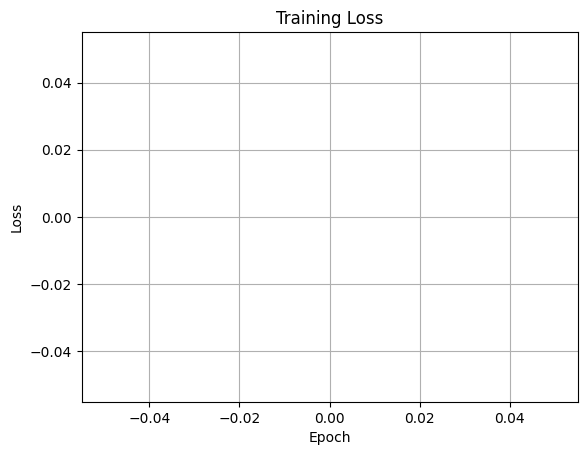

In [23]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

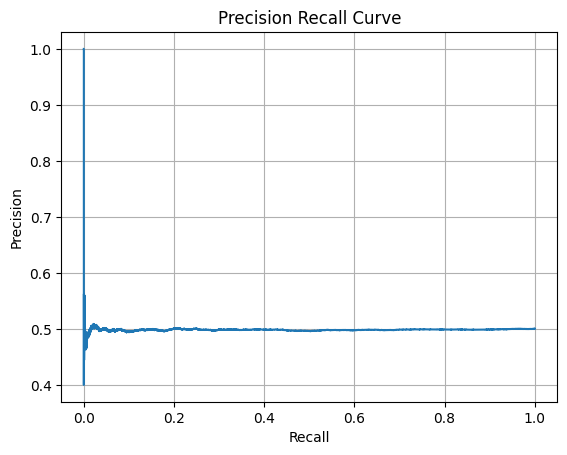

In [25]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

image,mask=next(iter(loader))

prediction=torch.sigmoid(model(image))

y_true=mask.flatten().detach().numpy()

y_score=prediction.flatten().detach().numpy()

precision,recall,_=precision_recall_curve(
    y_true,
    y_score
)

plt.plot(recall,precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.grid()

plt.show()

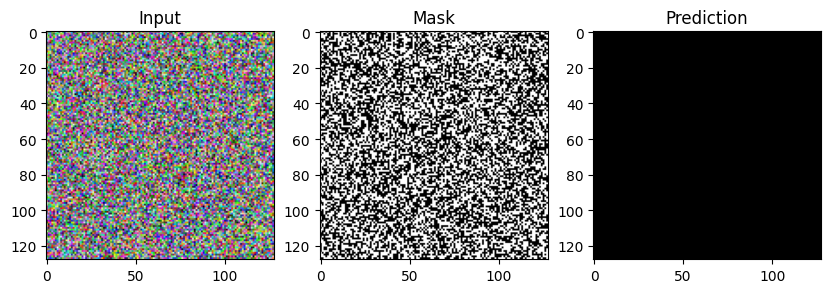

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(image[0].permute(1,2,0))
plt.title("Input")

plt.subplot(1,3,2)
plt.imshow(mask[0][0],cmap="gray")
plt.title("Mask")

plt.subplot(1,3,3)
plt.imshow(prediction[0][0].detach()>0.5,cmap="gray")
plt.title("Prediction")

plt.show()